# Figure 10 — Out-of-distribution transfer to EDF-S (no retraining)

The frozen foundation and the heads trained **only on ECDFS** are applied to the held-out
**EDF-S** field (72 tiles, a separate Euclid Deep Field, never seen in training) with **no
retraining or fine-tuning**.

- **(a) Detection transfer:** completeness and purity vs detection threshold, in-distribution
  (ECDFS, solid) vs out-of-distribution (EDF-S, dashed), scored against each field's clean
  Euclid Q1 MER catalogue. Both completeness and purity transfer almost exactly (EDF-S
  93.4/93.1 vs ECDFS 93.3/94.5 at the 0.30 working point). Purity is measured **within the MER
  footprint**: the EDF-S MER catalogue covers only a thin Dec strip, so $\sim$20% of detections
  fall outside its coverage and are not true false positives (see the diagnostic panel below);
  scoring them naively drops the apparent purity to $\sim$76%.
- **(b) Astrometry transfer:** per-band head-corrected median cross-survey offset, ECDFS vs
  EDF-S. The grey ghost bars mark the raw (pre-head) offsets; the alignment head collapses them
  to the same $\sim$12--18\,mas floor on the unseen field as in-distribution.

Reads the four cached evals (`edfs_ood_metrics.json`, `bakeoff_metrics.json`,
`eval_edfs/results.json`, `eval_centernet/results.json`). Saves `paper/figures/fig10_ood.png`.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO=find_repo_root()
OUT=REPO/'paper'/'figures'/'fig10_ood.png'

# ---- detection: completeness/purity vs threshold, ECDFS (in-dist) vs EDF-S (OOD) ----
ec_det = json.load(open(REPO/'checkpoints/q1_detection/bakeoff_metrics.json'))['cn_vis_sep']['rows']
oo_det = json.load(open(REPO/'checkpoints/q1_detection/edfs_ood_metrics.json'))['rows']
def sweep(rows):
    ks=sorted(rows, key=float); c=[float(k) for k in ks]
    return np.array(c), np.array([rows[k]['completeness'] for k in ks]), np.array([rows[k]['purity'] for k in ks])
ec_c, ec_comp, ec_pur = sweep(ec_det)
oo_c, oo_comp, oo_pur = sweep(oo_det)

# ---- astrometry: per-band head-corrected median, ECDFS vs EDF-S ----
ec_ast = json.load(open(REPO/'models/checkpoints/latent_position_q1_vissep/eval_centernet/results.json'))['per_band']
oo_ast = json.load(open(REPO/'models/checkpoints/latent_position_q1_vissep/eval_edfs/results.json'))['per_band']
BANDS=['rubin_u','rubin_g','rubin_r','rubin_i','rubin_z','rubin_y','nisp_Y','nisp_J','nisp_H']
LAB=['u','g','r','i','z','y','Y','J','H']
ec_head=np.array([ec_ast[b]['head_median_mas'] for b in BANDS])
oo_head=np.array([oo_ast[b]['head_median_mas'] for b in BANDS])
ec_raw =np.array([ec_ast[b]['raw_median_mas']  for b in BANDS])
oo_raw =np.array([oo_ast[b]['raw_median_mas']  for b in BANDS])
raw_ghost=0.5*(ec_raw+oo_raw)   # mean raw (before head), context
print('detection @0.30  ECDFS comp/pur:', ec_det.get('0.3',ec_det.get('0.30')))
print('detection @0.30  EDF-S comp/pur:', oo_det.get('0.3',oo_det.get('0.30')))
print('astrom head med (mas)  ECDFS:', dict(zip(LAB, ec_head.round(1))))
print('astrom head med (mas)  EDF-S:', dict(zip(LAB, oo_head.round(1))))

detection @0.30  ECDFS comp/pur: {'completeness': 93.3, 'purity': 94.5, 'f1': 93.9, 'n_det': 25209}
detection @0.30  EDF-S comp/pur: {'completeness': 93.4, 'purity': 93.1, 'purity_unrestricted': 75.6, 'f1': 93.2, 'n_det': 19780, 'n_det_footprint': 15842}
astrom head med (mas)  ECDFS: {'u': 39.4, 'g': 15.4, 'r': 13.8, 'i': 12.9, 'z': 13.4, 'y': 17.3, 'Y': 12.7, 'J': 12.5, 'H': 12.5}
astrom head med (mas)  EDF-S: {'u': 38.6, 'g': 18.5, 'r': 16.1, 'i': 16.0, 'z': 16.4, 'y': 19.2, 'Y': 12.6, 'J': 12.3, 'H': 13.0}


saved paper/figures/fig10_ood.png


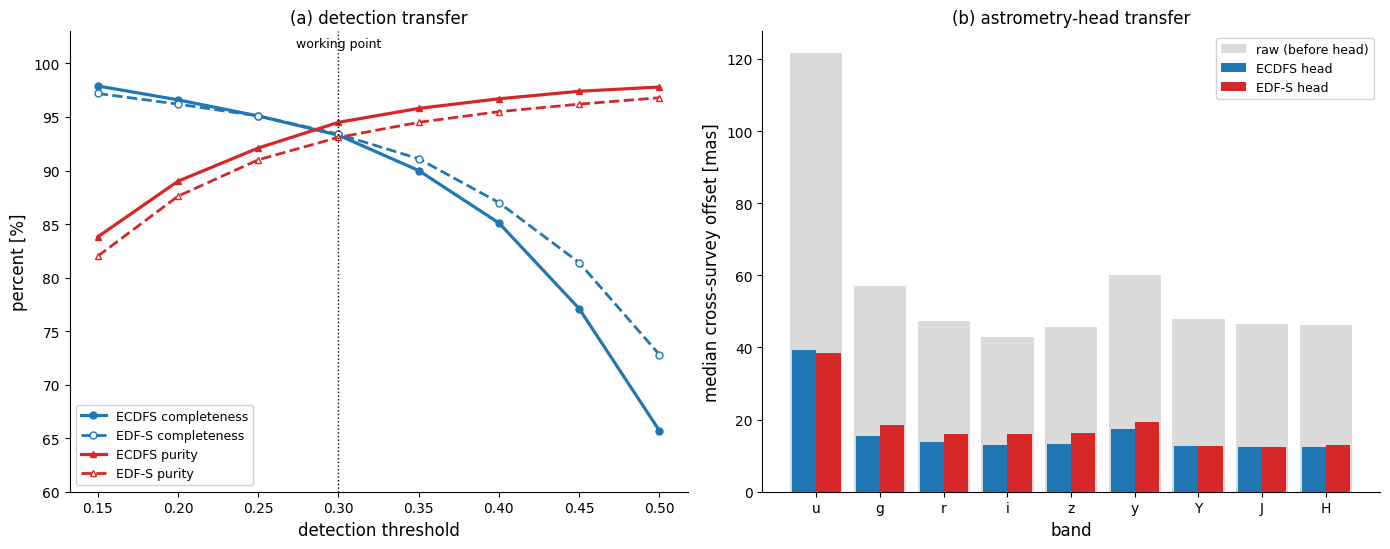

In [2]:
CE, CO = '#1f77b4', '#d62728'   # ECDFS blue, EDF-S red
fig, (a, b) = plt.subplots(1, 2, figsize=(14, 5.6))

# ---- (a) detection completeness/purity vs threshold ----
a.plot(ec_c, ec_comp, '-o', color=CE, lw=2.3, ms=5, label='ECDFS completeness')
a.plot(oo_c, oo_comp, '--o', color=CE, lw=2.0, ms=5, mfc='white', label='EDF-S completeness')
a.plot(ec_c, ec_pur,  '-^', color=CO, lw=2.3, ms=5, label='ECDFS purity')
a.plot(oo_c, oo_pur,  '--^', color=CO, lw=2.0, ms=5, mfc='white', label='EDF-S purity')
a.axvline(0.30, color='k', lw=1.0, ls=':'); a.text(0.30, 101.5, 'working point', fontsize=9, ha='center')
a.set_xlabel('detection threshold', fontsize=12); a.set_ylabel('percent [%]', fontsize=12)
a.set_ylim(60, 103); a.set_title('(a) detection transfer', fontsize=12)
a.legend(fontsize=9, loc='lower left', ncol=1, framealpha=0.9); a.tick_params(labelsize=10)

# ---- (b) astrometry head-corrected median per band ----
x=np.arange(len(BANDS)); w=0.38
b.bar(x, raw_ghost, width=0.82, color='0.86', zorder=0, label='raw (before head)')
b.bar(x-w/2, ec_head, w, color=CE, zorder=3, label='ECDFS head')
b.bar(x+w/2, oo_head, w, color=CO, zorder=3, label='EDF-S head')
b.set_xticks(x); b.set_xticklabels(LAB, fontsize=10)
b.set_xlabel('band', fontsize=12); b.set_ylabel('median cross-survey offset [mas]', fontsize=12)
b.set_title('(b) astrometry-head transfer', fontsize=12)
b.legend(fontsize=9, loc='upper right', framealpha=0.9); b.tick_params(labelsize=10)

for ax in (a, b):
    for s in ('top','right'): ax.spines[s].set_visible(False)
fig.tight_layout()
OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT, dpi=200, bbox_inches='tight', facecolor='white')
print('saved', OUT.relative_to(REPO)); plt.show()

## Diagnostic — why is EDF-S detection purity lower?

Overlay of the production detections on a real EDF-S VIS tile against the clean MER catalogue.
Auto-picks the **worst-purity** tile (most unmatched detections) for the clearest view.
\emph{Green circles} = clean MER sources; \emph{cyan +} = detections matched to MER;
\emph{red x} = detections with NO MER match (what drives the purity number down). The printed
median peak-S/N of unmatched vs matched detections tells whether the unmatched ones are real
sources MER missed (high S/N, on visible objects) or genuine false positives (low S/N / on
bright-star halos).

TILE: tile_x01792_y01536
dets=296  matched=41  unmatched=255  tile purity=14%
median peak S/N   matched=4.7   unmatched=5.2
unmatched with peak S/N>5: 51%  (high-S/N unmatched = real sources MER omitted)


saved fig10_ood_purity_overlay.png


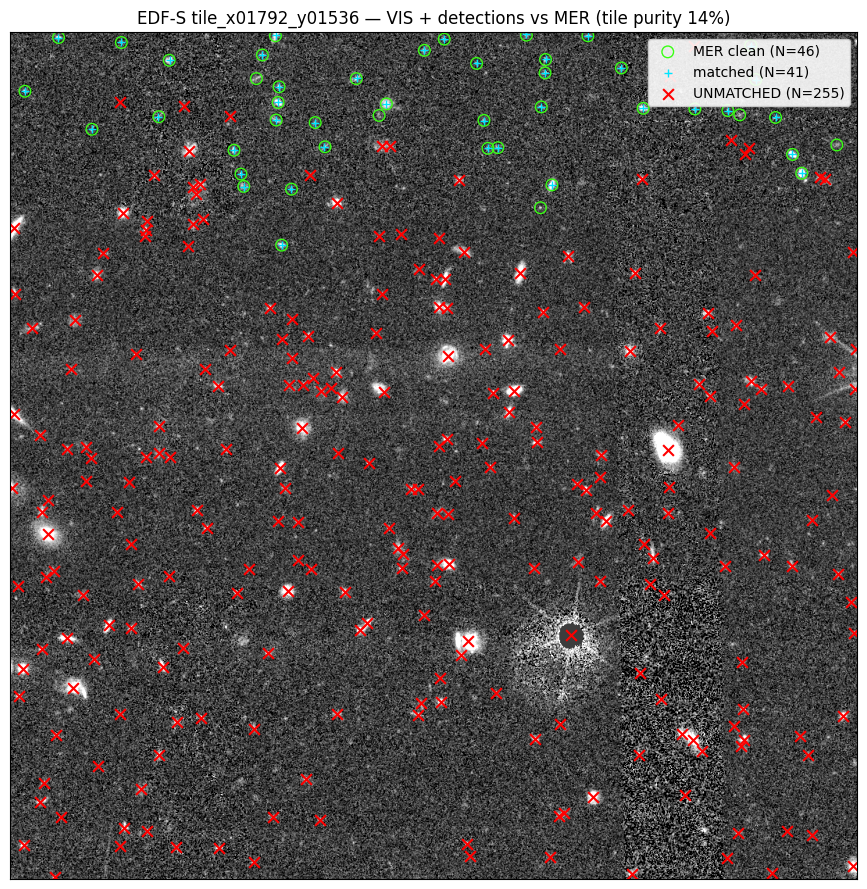

In [3]:
import sys, numpy as np, torch
from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from scipy.spatial import cKDTree
sys.path.insert(0, str(REPO/'models'))
from astrometry2.source_matching import safe_header_from_card_string

MATCH_PX = 5.0                       # 0.5" at 0.1"/px, same as the eval crossmatch
EU   = REPO/'data/edf_s_ood/euclid_tiles_edfs_q1'
seed = torch.load(REPO/'data/detection_labels/centernet_q1_edfs_vissep_thresh03.pt', weights_only=False)
LAB  = seed['labels']
mer  = Table.read(REPO/'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_TILE102021011_footprint.fits')
clean = (np.asarray(mer['vis_det'])==1) & (np.asarray(mer['spurious_flag'])==0)
mra, mdec = np.asarray(mer['ra'])[clean], np.asarray(mer['dec'])[clean]

z0=np.load(EU/f'{list(LAB)[0]}_euclid.npz', allow_pickle=True); H,W=np.asarray(z0['img_VIS']).shape
def wcs_of(stem):
    z=np.load(EU/f'{stem}_euclid.npz', allow_pickle=True)
    return WCS(safe_header_from_card_string(z['wcs_VIS'].item()))
def det_px(stem):
    xy=np.asarray(LAB[stem][0] if isinstance(LAB[stem],tuple) else LAB[stem], float)
    return np.c_[xy[:,0]*(W-1), xy[:,1]*(H-1)]
def unmatched_count(stem):
    w=wcs_of(stem); d=det_px(stem)
    cx,cy=w.all_world2pix(mra,mdec,0); inb=(cx>3)&(cx<W-3)&(cy>3)&(cy<H-3)
    if inb.sum()<2 or len(d)<1: return -1
    dist,_=cKDTree(np.c_[cx[inb],cy[inb]]).query(d); return int((dist>MATCH_PX).sum())

TILE = None   # None -> auto-pick worst purity; or set e.g. 'tile_x01024_y01536'
if TILE is None:
    counts={s:unmatched_count(s) for s in LAB}
    TILE=max(counts, key=counts.get)
print('TILE:', TILE)

z=np.load(EU/f'{TILE}_euclid.npz', allow_pickle=True)
vis=np.nan_to_num(np.asarray(z['img_VIS'],float))
var=np.nan_to_num(np.asarray(z['var_VIS'],float)) if 'var_VIS' in z.files else None
w=WCS(safe_header_from_card_string(z['wcs_VIS'].item()))
d=det_px(TILE)
cx,cy=w.all_world2pix(mra,mdec,0); inb=(cx>3)&(cx<W-3)&(cy>3)&(cy<H-3)
mx,my=cx[inb],cy[inb]
dist,_=cKDTree(np.c_[mx,my]).query(d); matched=dist<=MATCH_PX
xi=np.clip(d[:,0].astype(int),0,W-1); yi=np.clip(d[:,1].astype(int),0,H-1)
snr=vis[yi,xi]/np.sqrt(np.clip(var[yi,xi],1e-12,None)) if var is not None else np.full(len(d),np.nan)
print(f'dets={len(d)}  matched={matched.sum()}  unmatched={(~matched).sum()}  tile purity={100*matched.mean():.0f}%')
print(f'median peak S/N   matched={np.nanmedian(snr[matched]):.1f}   unmatched={np.nanmedian(snr[~matched]):.1f}')
print(f'unmatched with peak S/N>5: {100*np.mean(snr[~matched]>5):.0f}%  (high-S/N unmatched = real sources MER omitted)')

import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(11,11))
v=np.arcsinh(vis/(np.nanstd(vis)*0.5+1e-9)); lo,hi=np.nanpercentile(v,[5,99.5])
ax.imshow(v,origin='lower',cmap='gray',vmin=lo,vmax=hi)
ax.scatter(mx,my,s=70,facecolors='none',edgecolors='#39FF14',lw=1.0,label=f'MER clean (N={int(inb.sum())})')
ax.scatter(d[matched,0],d[matched,1],s=28,marker='+',c='#00e5ff',lw=1.0,label=f'matched (N={int(matched.sum())})')
ax.scatter(d[~matched,0],d[~matched,1],s=60,marker='x',c='red',lw=1.5,label=f'UNMATCHED (N={int((~matched).sum())})')
ax.set_title(f'EDF-S {TILE} — VIS + detections vs MER (tile purity {100*matched.mean():.0f}%)',fontsize=12)
ax.legend(loc='upper right',fontsize=10,framealpha=0.9); ax.set_xticks([]); ax.set_yticks([])
OUTD=REPO/'paper'/'figures'/'fig10_ood_purity_overlay.png'
fig.savefig(OUTD,dpi=160,bbox_inches='tight',facecolor='white'); print('saved',OUTD.name); plt.show()